# Diseñar una capa entrenable que represente un polinomio grado 3: 
# $f (x) = a_0 + a_1x + a_2x^2 + a_3x^3$ .
# Los parámetros entrenables son los coefientes $a_0$ , $a_1$ , $a_2$ , $a_3$ . Posteriormente, entrenarla para ajustarla a la función $f(x) = cos(2x)$ en el intervalo [-1,1].

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, metrics, Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from keras.optimizers import Adam
import numpy as np

In [19]:
class CapaPolinomio(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        self.w = self.add_weight(
            name="coeficientes_polinomio",
            shape=(4,),
            initializer="random_normal",
            trainable=True,
            dtype=tf.float32
        )
        super().build(input_shape)

    def call(self, inputs):
        """La salida de la red es la aprox del polinomio"""
        x = inputs
        poli = self.w[0] + self.w[1] * x + self.w[2] * (x ** 2) + self.w[3] * (x ** 3)
        return poli

    def get_config(self):
        return super().get_config()

## Reusamos la clase ModeloFunción del inciso 2 para ajustar a la función $cos(2x)$

In [20]:
class ModeloFuncion(Sequential):
    def __init__(self,layers=None, name=None):
        super().__init__(layers=layers, name=name)
        self.loss_tracker = metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        """La forma de y debe de tener la forma de la función objetivo"""
        x, y = data
        pi = tf.constant(np.pi, dtype=tf.float32)

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = tf.reduce_mean(tf.square(y_pred - y))

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

## Ajuste de la función $cos(2x)$ con la capa Polinomio

In [21]:
model = ModeloFuncion()
model.add(CapaPolinomio(input_shape=(1,)))
model.summary()

/tmp/ipykernel_2995091/2036649374.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "modelo_funcion_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_polinomio_2                │ (None, 1)              │             4 │
│ (CapaPolinomio)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
num_muestras = 1000
x = tf.random.uniform((num_muestras,1), minval=-1, maxval=1)
y = tf.math.cos(2*x) #Funcion objetivo
model.compile(optimizer=Adam(learning_rate=0.001), metrics=['loss'])
history = model.fit(x=x,y=y,epochs=1000,verbose=0,batch_size=64)

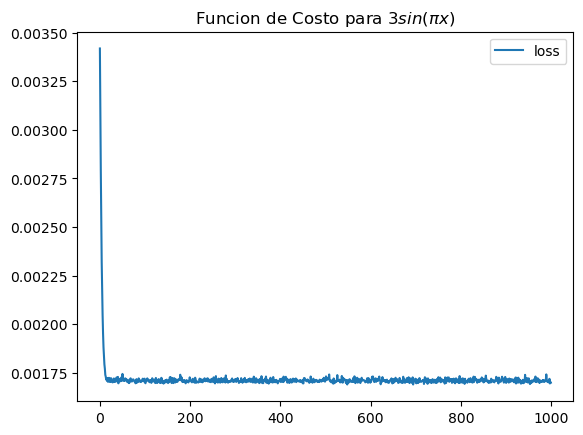

In [27]:
plt.plot(history.history["loss"], label='loss')
plt.title(r"Funcion de Costo para $3 sin(\pi x)$")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


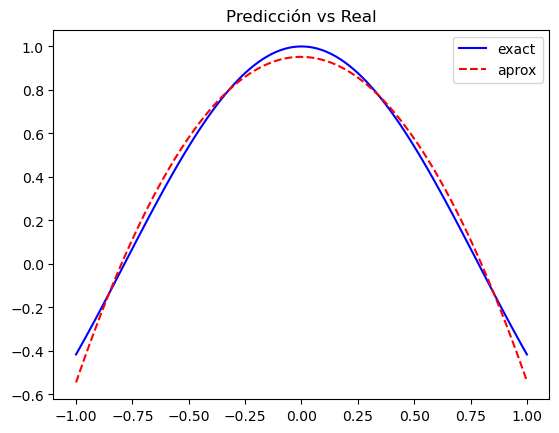

In [28]:
x=tf.linspace(-1,1,100)
y_pred=model.predict(x)
plt.plot(x, np.cos(2*x), label="exact", color='blue')
plt.plot(x,y_pred,label="aprox", color='red', linestyle='--')
plt.title("Predicción vs Real")
plt.legend()
plt.show()